In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/kaggle/input/datasets/meruvulikith/190k-spam-ham-email-dataset-for-classification/spam_Emails_data.csv')
print("Shape   :", df.shape)
print("Columns :", df.columns.tolist())

text_col  = "text"
label_col = "label"

df = df[[text_col, label_col]].dropna().reset_index(drop=True)

df['label'] = df[label_col].str.strip().str.lower()

df["label_int"] = df[label_col].map({"spam": 1, "ham": 0})

df = df.dropna(subset=["label_int"])

print(f"Total emails  : {len(df)}")
print(f"Spam emails   : {(df['label_int'] == 1).sum()}")
print(f"Ham  emails   : {(df['label_int'] == 0).sum()}")
print(f"Spam ratio    : {df['label_int'].mean():.2%}")

Shape   : (193852, 2)
Columns : ['label', 'text']
Total emails  : 193850
Spam emails   : 91691
Ham  emails   : 102159
Spam ratio    : 47.30%


In [5]:
# Text Cleaning

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " url ", text)
    text = re.sub(r"\S+@\S+",  " email ", text)
    text = re.sub(r"\d+",   " num ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [7]:
print("Sample cleaned email:")
print(df["clean_text"].iloc[0][:500])

Sample cleaned email:
viiiiiiagraaaa only for the ones that want to make her scream prodigy scrawny crow define upgrade spongy balboa dither moiseyev schumann variegate ponce bernie cox angeles impassive circulate impend miscellany chalkboard whizzing pend armenian cutlet waring makeshift fletch dispel crest cadet dovetail rapprochement gerry bayreuth selectman wilmington tuttle alchemy itt bullyboy caan t do


In [8]:
# Train Test Split

X = df["clean_text"].values
y = df["label_int"].values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_test)}")

Train : 155080
Val   : 19385
Test  : 19385


In [9]:
# Tokenization 

tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(X_train)

vocab_size = min(10000, len(tokenizer.word_index) + 1)


X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=150, padding="post", truncating="post"
)

X_val_pad = tf.keras.preprocessing.sequence.pad_sequences(
    tokenizer.texts_to_sequences(X_val),
    maxlen=150, padding="post", truncating="post"
)

X_test_pad = tf.keras.preprocessing.sequence.pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=150, padding="post", truncating="post"
)

In [10]:
# Data Pipeline 

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train_pad, y_train))
            .cache().shuffle(10000).batch(256).prefetch(AUTOTUNE))

val_ds   = (tf.data.Dataset.from_tensor_slices((X_val_pad, y_val))
            .cache().batch(256).prefetch(AUTOTUNE))

test_ds  = (tf.data.Dataset.from_tensor_slices((X_test_pad, y_test))
            .cache().batch(256).prefetch(AUTOTUNE))

I0000 00:00:1782652940.699010      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782652940.704869      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
#  Model Architecture

inputs = tf.keras.Input(shape=(150,))

x = layers.Embedding(
    input_dim=vocab_size,
    output_dim=64,
    input_length=150
)(inputs)

x = layers.SpatialDropout1D(0.3)(x)

# Bidirectional GRU (faster than LSTM, no recurrent_dropout = CuDNN enabled)
x = layers.Bidirectional(
    layers.GRU(64, return_sequences=True)   # NO recurrent_dropout
)(x)

x = layers.Bidirectional(
    layers.GRU(32, return_sequences=False)  # NO recurrent_dropout
)(x)

x = layers.Dense(
    64, activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# ── dtype=float32 on output is required for mixed precision ──
outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)

model = models.Model(inputs, outputs)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 128)       │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 725,505 (2.77 MB)

 Trainable params: 725,377 (2.77 MB)

 Non-trainable params: 128 (512.00 B)

In [12]:
# Callbacks

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_spam_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [13]:
# Compile & Train

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/15


I0000 00:00:1782652947.668529     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9065 - loss: 0.2433 - precision: 0.9027 - recall: 0.8981
Epoch 1: val_accuracy improved from None to 0.97539, saving model to best_spam_model.keras

Epoch 1: finished saving model to best_spam_model.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.9551 - loss: 0.1401 - precision: 0.9519 - recall: 0.9532 - val_accuracy: 0.9754 - val_loss: 0.0814 - val_precision: 0.9877 - val_recall: 0.9600 - learning_rate: 0.0010
Epoch 2/15
605/606 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9830 - loss: 0.0588 - precision: 0.9800 - recall: 0.9843
Epoch 2: val_accuracy improved from 0.97539 to 0.97962, saving model to best_spam_model.keras

Epoch 2: finished saving model to best_spam_model.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9841 - loss: 0.0532 - precision: 0.9815 - recall: 0.9850 - val_accuracy: 0.9796 - val_loss: 0.0627 - val_precision: 0.9805 - val_recall: 0.9763 - learning_rate: 0.0010
Epoch 3/15
605

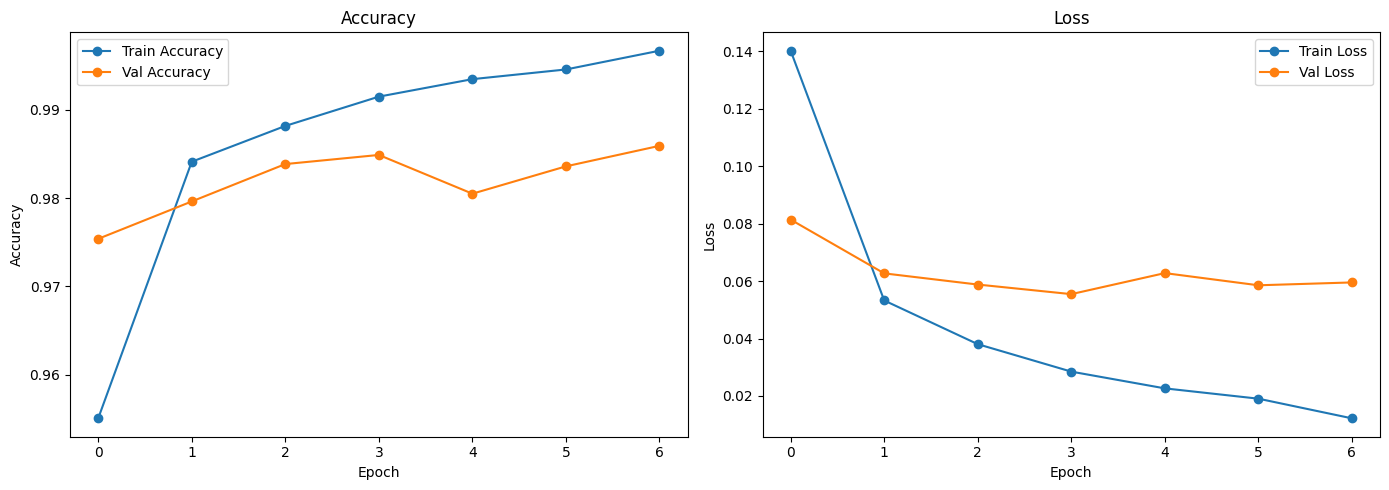

In [22]:
# Training Plot

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"],     label="Train Accuracy", marker='o')
plt.plot(history.history["val_accuracy"], label="Val Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"],     label="Train Loss", marker='o')
plt.plot(history.history["val_loss"], label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Evaluation 

model = tf.keras.models.load_model("best_spam_model.keras")

test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds, verbose=1)
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-8)

print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1-Score  : {f1:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9845 - loss: 0.0711 - precision: 0.9830 - recall: 0.9843
Test Accuracy  : 0.9845
Test Precision : 0.9830
Test Recall    : 0.9843
Test F1-Score  : 0.9837



Classification Report:
              precision    recall  f1-score   support

         Ham     0.9859    0.9847    0.9853     10216
        Spam     0.9830    0.9843    0.9837      9169

    accuracy                         0.9845     19385
   macro avg     0.9844    0.9845    0.9845     19385
weighted avg     0.9845    0.9845    0.9845     19385



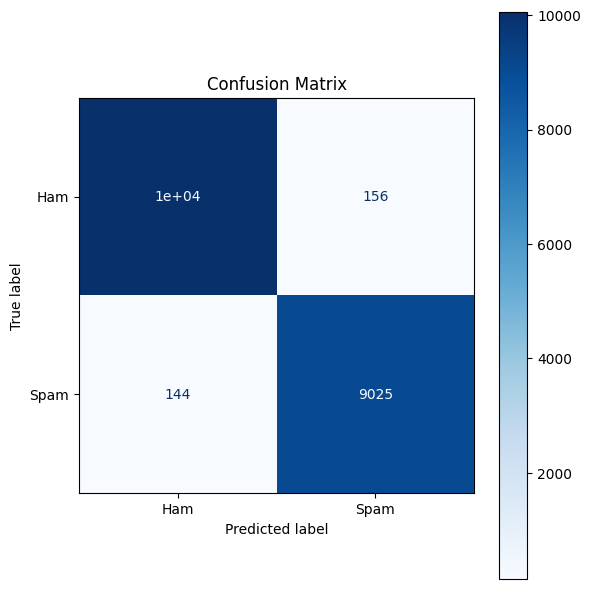

In [16]:
# Confusion Matrix

y_true, y_pred_prob = [], []
for texts, labels in test_ds:
    probs = model.predict(texts, verbose=0)
    y_pred_prob.extend(probs.flatten())
    y_true.extend(labels.numpy())

y_pred = (np.array(y_pred_prob) >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Ham", "Spam"], digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
# Predict Raw Emails

sample_emails = [
    "Congratulations! You have won a FREE iPhone. Click here to claim now!!!",
    "Hi John, please find attached the meeting agenda for tomorrow.",
    "URGENT: Your bank account has been suspended. Verify immediately.",
    "Can we reschedule our call to 3pm? Let me know what works for you.",
    "Win cash prizes! Limited time offer. Call now 1-800-SPAM-123"
]

cleaned   = [clean_text(e) for e in sample_emails]
sequences = tokenizer.texts_to_sequences(cleaned)
padded    = tf.keras.preprocessing.sequence.pad_sequences(
    sequences, maxlen=150, padding="post", truncating="post"
)
probs       = model.predict(padded, verbose=0).flatten()
predictions = ["SPAM 🚨" if p >= 0.5 else "HAM  ✅" for p in probs]

print("Sample Predictions")
for email, pred, prob in zip(sample_emails, predictions, probs):
    print(f"\nEmail  : {email[:80]}")
    print(f"Result : {pred}  (confidence: {prob:.4f})")

Sample Predictions

Email  : Congratulations! You have won a FREE iPhone. Click here to claim now!!!
Result : SPAM 🚨  (confidence: 0.9985)

Email  : Hi John, please find attached the meeting agenda for tomorrow.
Result : HAM  ✅  (confidence: 0.0001)

Email  : URGENT: Your bank account has been suspended. Verify immediately.
Result : SPAM 🚨  (confidence: 0.9995)

Email  : Can we reschedule our call to 3pm? Let me know what works for you.
Result : HAM  ✅  (confidence: 0.0013)

Email  : Win cash prizes! Limited time offer. Call now 1-800-SPAM-123
Result : SPAM 🚨  (confidence: 0.9979)


In [18]:
# Predict Raw Emails

sample_emails = [
    """
    Subject: Following up on our previous conversation regarding your website traffic!
    Hi [Your Name],
    I hope this email finds you well.
    I’m reaching out because I noticed a few technical SEO issues on [Your Company Website] that might be limiting your organic growth in the Hyderabad region. 
    We’ve recently helped similar local businesses increase their leads by over 40%.
    """]

cleaned   = [clean_text(e) for e in sample_emails]
sequences = tokenizer.texts_to_sequences(cleaned)
padded    = tf.keras.preprocessing.sequence.pad_sequences(
    sequences, maxlen=150, padding="post", truncating="post"
)
probs       = model.predict(padded, verbose=0).flatten()
predictions = ["SPAM 🚨" if p >= 0.5 else "HAM  ✅" for p in probs]

print("Sample Predictions")
for email, pred, prob in zip(sample_emails, predictions, probs):
    print(f"\nEmail  : {email[:80]}")
    print(f"Result : {pred}  (confidence: {prob:.4f})")

Sample Predictions

Email  : Subject: Following up on our previous conversation regarding your website traffi
Result : SPAM 🚨  (confidence: 0.9003)


In [19]:
# Predict Raw Emails

sample_emails = [
    """
    Subject: Meeting Confirmation: Q3 Strategy Review – Oct 15
    From: sarah.jenkins@company.com
    To: alex.miller@company.com
    Hi Alex,Just confirming our Q3 strategy review for next Tuesday, October 15th, at 10:00 AM.
    I’ve booked Conference Room B and attached the agenda for everyone to review beforehand.
    Please let me know if you need to adjust the time.
    Best regards,
    Sarah Jenkins
    Operations Manager"
    """]

cleaned   = [clean_text(e) for e in sample_emails]
sequences = tokenizer.texts_to_sequences(cleaned)
padded    = tf.keras.preprocessing.sequence.pad_sequences(
    sequences, maxlen=150, padding="post", truncating="post"
)
probs       = model.predict(padded, verbose=0).flatten()
predictions = ["SPAM 🚨" if p >= 0.5 else "HAM  ✅" for p in probs]

print("Sample Predictions")
for email, pred, prob in zip(sample_emails, predictions, probs):
    print(f"\nEmail  : {email[:80]}")
    print(f"Result : {pred}  (confidence: {prob:.4f})")

Sample Predictions

Email  : Subject: Meeting Confirmation: Q3 Strategy Review – Oct 15From: sarah.jenkins@co
Result : HAM  ✅  (confidence: 0.0002)
